In [2]:
!pip install kagglehub -q
import kagglehub
import pandas as pd
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


In [3]:
# Download dataset
path = kagglehub.dataset_download("rabieelkharoua/predict-online-gaming-behavior-dataset")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

## Elements cheking

In [11]:
df.columns

Index(['PlayerID', 'Age', 'Gender', 'Location', 'GameGenre', 'PlayTimeHours',
       'InGamePurchases', 'GameDifficulty', 'SessionsPerWeek',
       'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked',
       'EngagementLevel'],
      dtype='object')

## Decision Tree Classification with Hyperparameter Tuning (GridSearchCV + Stratified Cross-Validation)

In [87]:
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# =========================
# Features
# =========================
X = df.drop(columns=['EngagementLevel'])
y = df['EngagementLevel']

# =========================
# One-Hot Encoding
# =========================
X = pd.get_dummies(X, drop_first=True)

# =========================
# Train / Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=== Dataset Size ===")
print("Train set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print("Total samples:", X.shape[0])

# ======================================================
# GRID SEARCH (Decision Tree tuning)
# ======================================================
param_grid = {
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

dt_base = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)

grid_search = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# =========================
# Best model
# =========================
dt_model = grid_search.best_estimator_

print("\n=== BEST PARAMETERS (Decision Tree) ===")
print(grid_search.best_params_)

print("\n=== CV BEST SCORE (F1 Macro) ===")
print(grid_search.best_score_)

# =========================
# Final Evaluation
# =========================
y_pred_best = dt_model.predict(X_test)
y_proba_best = dt_model.predict_proba(X_test)

roc_auc_best = roc_auc_score(
    y_test,
    y_proba_best,
    multi_class='ovr',
    average='macro'
)

print("\n=== FINAL MODEL RESULTS (Decision Tree) ===")
print(f"ROC-AUC: {roc_auc_best:.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(classification_report(y_test, y_pred_best))

=== Dataset Size ===
Train set size: 32027
Test set size: 8007
Total samples: 40034

=== BEST PARAMETERS (Decision Tree) ===
{'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}

=== CV BEST SCORE (F1 Macro) ===
0.8934609301533072

=== FINAL MODEL RESULTS (Decision Tree) ===
ROC-AUC: 0.9290
Accuracy: 0.8983
              precision    recall  f1-score   support

        High       0.89      0.88      0.89      2067
         Low       0.88      0.88      0.88      2065
      Medium       0.91      0.92      0.91      3875

    accuracy                           0.90      8007
   macro avg       0.89      0.89      0.89      8007
weighted avg       0.90      0.90      0.90      8007



## Data Preprocessing: Encoding, and One-Hot Transformation

In [88]:
from sklearn.preprocessing import LabelEncoder

# Clean column names (Prevents KeyError caused by hidden spaces)
df.columns = df.columns.str.strip()

# 2. Define the "core features" to keep (PlayerID is excluded, effectively removing it)
selected_columns = [
    'Age', 'Gender', 'GameGenre', 'PlayTimeHours', 'InGamePurchases', 
    'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 
    'AchievementsUnlocked', 'Location', 'EngagementLevel'
]

# Extract data using .loc (Using your 'data' variable directly)
# If your variable is named 'data', do not use 'df'
df_final = df.loc[:, selected_columns].copy()

# Convert data types (This step is necessary for the model to process the data)
df_final['EngagementLevel'] = df_final['EngagementLevel'].map({'Low': 0, 'Medium': 1, 'High': 2})
df_final['Gender'] = LabelEncoder().fit_transform(df_final['Gender'])
df_final = pd.get_dummies(df_final, columns=['Location', 'GameGenre'])

df_final.head(10)

,Age,Gender,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,Location_Asia,Location_Europe,Location_Other,Location_USA,GameGenre_Action,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy
0,43,1,16.271119,0,6,108,79,25,1,False,False,True,False,False,False,False,False,True
1,29,0,5.525961,0,5,144,11,10,1,False,False,False,True,False,False,False,False,True
2,22,0,8.223755,0,16,142,35,41,2,False,False,False,True,False,False,False,True,False
3,35,1,5.265351,1,9,85,57,47,1,False,False,False,True,True,False,False,False,False
4,33,1,15.531945,0,2,131,95,37,1,False,True,False,False,True,False,False,False,False
5,37,1,20.561855,0,2,81,74,22,0,False,True,False,False,False,True,False,False,False
6,25,1,9.752716,0,1,50,13,2,0,False,False,False,True,True,False,False,False,False
7,25,0,4.401729,0,10,48,27,23,1,True,False,False,False,False,True,False,False,False
8,38,0,18.152733,0,5,101,23,41,1,False,True,False,False,False,False,True,False,False
9,38,0,23.942772,0,13,95,99,36,2,False,False,True,False,False,False,False,True,False


## Model Interpretability Using Permutation Importance (Test Set Evaluation)

                      Feature  Importance       Std
4             SessionsPerWeek    0.425372  0.006101
5   AvgSessionDurationMinutes    0.353387  0.007215
6                 PlayerLevel    0.024084  0.002086
7        AchievementsUnlocked    0.022778  0.001241
9             Location_Europe    0.000256  0.000212
1                         Age    0.000223  0.000273
14           GameGenre_Sports    0.000109  0.000173
3             InGamePurchases    0.000062  0.000207
0                    PlayerID    0.000046  0.000495
8                 Gender_Male    0.000000  0.000000
11               Location_USA    0.000000  0.000000
12              GameGenre_RPG    0.000000  0.000000
16        GameDifficulty_Hard    0.000000  0.000000
17      GameDifficulty_Medium    0.000000  0.000000
13       GameGenre_Simulation   -0.000027  0.000519
15         GameGenre_Strategy   -0.000224  0.000163
2               PlayTimeHours   -0.000345  0.000361
10             Location_Other   -0.000372  0.000163


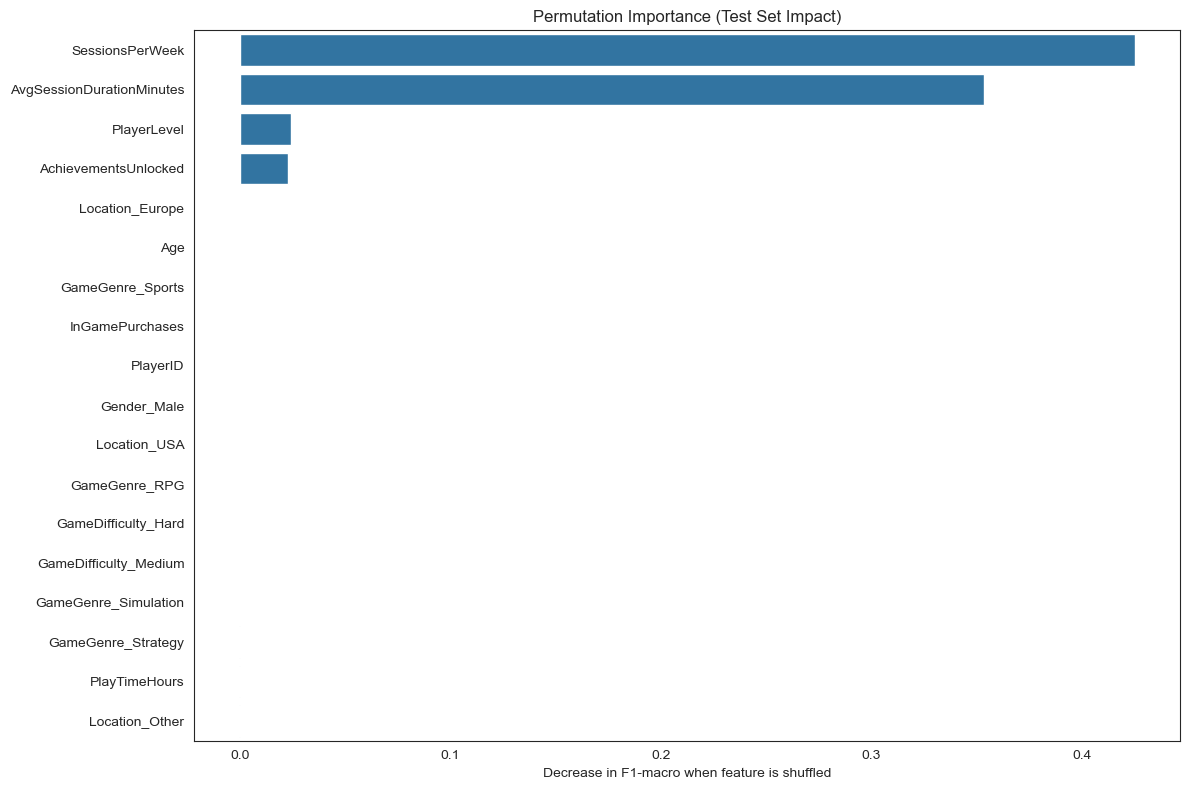

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.inspection import permutation_importance

# ======================================================
# 🔥 Permutation Importance (TEST SET)
# ======================================================
result = permutation_importance(
    dt_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1_macro'   # 你也可以换 accuracy / roc_auc
)

# ======================================================
# 📊 Build dataframe
# ======================================================
perm_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': result.importances_mean,
    'Std': result.importances_std
}).sort_values(by='Importance', ascending=False)

print(perm_df)
#======display======
plt.figure(figsize=(12,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=perm_df
)

plt.title("Permutation Importance (Test Set Impact)")
plt.xlabel("Decrease in F1-macro when feature is shuffled")
plt.ylabel("")
plt.tight_layout()
plt.show()

# Analysis of the contribution of different features to model learning (split dats set version)

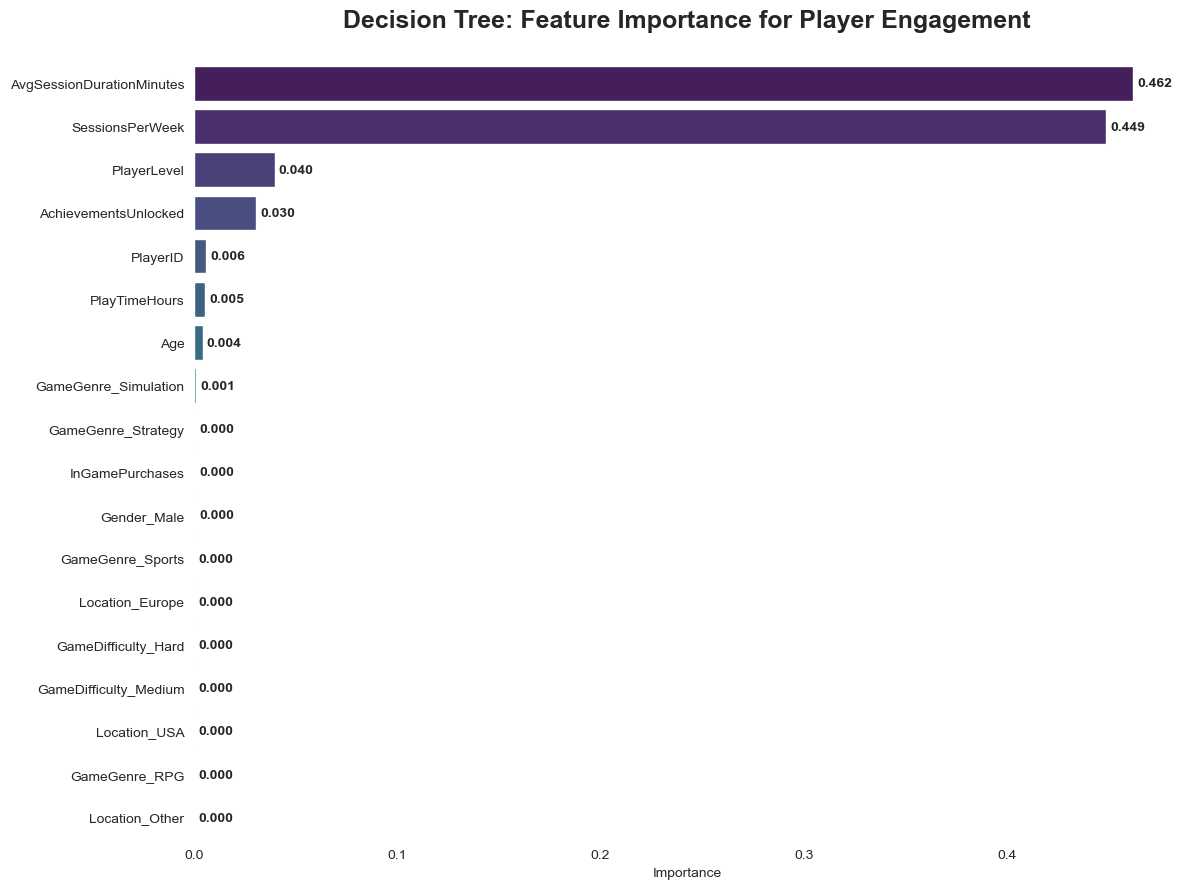

Total samples: 40034
Number of features: 18


In [89]:
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Feature Importance
# =========================
importances = dt_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


# =========================
# Plot
# =========================
plt.figure(figsize=(12, 9))
sns.set_style("white")

ax = sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df,
    palette='viridis',
    hue='Feature',
    legend=False
)

# --- Value labels ---
for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + 0.002,
        p.get_y() + p.get_height()/2,
        f'{width:.3f}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Decision Tree: Feature Importance for Player Engagement',
          fontsize=18, fontweight='bold', pad=25)

plt.xlabel('Importance')
plt.ylabel('')
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

# =========================
# Info
# =========================
print(f"Total samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")

## Decision Tree Classification: Hyperparameter Optimization and Full vs Top-2 Feature Comparison

In [104]:
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, f1_score, precision_score, recall_score

# =========================
# Features
# =========================
X = df.drop(columns=['EngagementLevel'])
y = df['EngagementLevel']

# =========================
# One-Hot Encoding
# =========================
X = pd.get_dummies(X, drop_first=True)

# =========================
# Train / Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=== Dataset Size ===")
print("Train set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print("Total samples:", X.shape[0])

# ======================================================
# 🌳 FULL MODEL GRIDSEARCH (✔ YOUR REPLACED VERSION)
# ======================================================
param_grid = {
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

dt_base = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)

grid_search_f = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    return_train_score=True, 
    n_jobs=-1
)

grid_search_f.fit(X_train, y_train)


dt_model = grid_search_f.best_estimator_

print("\n=== BEST PARAMETERS (Decision Tree) ===")
print(grid_search_f.best_params_)

print("\n=== CV BEST SCORE (F1 Macro) ===")
print(grid_search_f.best_score_)

# ======================================================
# 🌳 FULL MODEL EVALUATION
# ======================================================
y_pred_best = dt_model.predict(X_test)
y_proba_best = dt_model.predict_proba(X_test)

roc_auc_best = roc_auc_score(
    y_test,
    y_proba_best,
    multi_class='ovr',
    average='macro'
)

print("\n=== Full features mODEL RESULTS (Decision Tree) ===")
print(f"ROC-AUC: {roc_auc_best:.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(classification_report(y_test, y_pred_best))

# ======================================================
# 🌿 FEATURE IMPORTANCE 
# ======================================================
feature_importance_df = pd.DataFrame({
    'Feature': dt_model.feature_names_in_,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

top2_features = feature_importance_df['Feature'].head(2).values

print("\n=== TOP 2 FEATURES ===")
print(top2_features)

# ======================================================
# TOP-2 MODEL (GRIDSEARCH)
# ======================================================
X_train2 = X_train[top2_features]
X_test2 = X_test[top2_features]

top2_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    return_train_score=True,
    n_jobs=-1
)

top2_grid.fit(X_train2, y_train)

top2_model = top2_grid.best_estimator_

print("\n=== TOP-2 BEST PARAMETERS ===")
print(top2_grid.best_params_)
print("\n=== CV BEST SCORE (F1 Macro) ===")
print(top2_grid.best_score_)

# ======================================================
# 🌿 TOP-2 EVALUATION
# ======================================================
y_pred_top2 = top2_model.predict(X_test2)
y_proba_top2 = top2_model.predict_proba(X_test2)

roc_auc_top2 = roc_auc_score(
    y_test,
    y_proba_top2,
    multi_class='ovr',
    average='macro'
)

print("\n=== TOP-2 model RESULTS ===")
print(f"ROC-AUC: {roc_auc_top2:.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_top2):.4f}")
print(classification_report(y_test, y_pred_top2))

# ======================================================
# 📊 FINAL COMPARISON
# ======================================================
print("\n================ GAP comparison (Full - Top 2) ================\n")

print("Accuracy gap:", accuracy_score(y_test, y_pred_best) - accuracy_score(y_test, y_pred_top2))
print("F1 gap:", f1_score(y_test, y_pred_best, average='macro') - f1_score(y_test, y_pred_top2, average='macro'))
print("ROC-AUC gap:", roc_auc_best - roc_auc_top2)

=== Dataset Size ===
Train set size: 32027
Test set size: 8007
Total samples: 40034

=== BEST PARAMETERS (Decision Tree) ===
{'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}

=== CV BEST SCORE (F1 Macro) ===
0.8934609301533072

=== Full features mODEL RESULTS (Decision Tree) ===
ROC-AUC: 0.9290
Accuracy: 0.8983
              precision    recall  f1-score   support

        High       0.89      0.88      0.89      2067
         Low       0.88      0.88      0.88      2065
      Medium       0.91      0.92      0.91      3875

    accuracy                           0.90      8007
   macro avg       0.89      0.89      0.89      8007
weighted avg       0.90      0.90      0.90      8007


=== TOP 2 FEATURES ===
['AvgSessionDurationMinutes' 'SessionsPerWeek']

=== TOP-2 BEST PARAMETERS ===
{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}

=== CV BEST SCORE (F1 Macro) ===
0.8759486518644184

=== TOP-2 model RESULTS

## CV mean

In [102]:
#===========full features==========
results_full = pd.DataFrame(grid_search_f.cv_results_)

best_idx_full = grid_search_f.best_index_

print("\n=== FULL MODEL CV MEAN ===")
print("Mean Train Score:", results_full.loc[best_idx_full, "mean_train_score"])
print("Mean Test Score (CV mean):", results_full.loc[best_idx_full, "mean_test_score"])
print("Overfit Gap:", results_full.loc[best_idx_full, "mean_train_score"] - results_full.loc[best_idx_full, "mean_test_score"])

#===========Top 2 features==========
results_top2 = pd.DataFrame(top2_grid.cv_results_)

best_idx_top2 = top2_grid.best_index_

print("\n=== TOP-2 MODEL CV MEAN ===")
print("Mean Train Score:", results_top2.loc[best_idx_top2, "mean_train_score"])
print("Mean Test Score (CV mean):", results_top2.loc[best_idx_top2, "mean_test_score"])
print("Overfit Gap:", results_top2.loc[best_idx_top2, "mean_train_score"] - results_top2.loc[best_idx_top2, "mean_test_score"])


=== FULL MODEL CV MEAN ===
Mean Train Score: 0.9175933984131668
Mean Test Score (CV mean): 0.8934609301533072
Overfit Gap: 0.024132468259859596

=== TOP-2 MODEL CV MEAN ===
Mean Train Score: 0.8832541857206513
Mean Test Score (CV mean): 0.8759486518644184
Overfit Gap: 0.007305533856232893


## Confusion Matrix Comparison: Full Feature vs Top-2 Feature Decision Tree Models

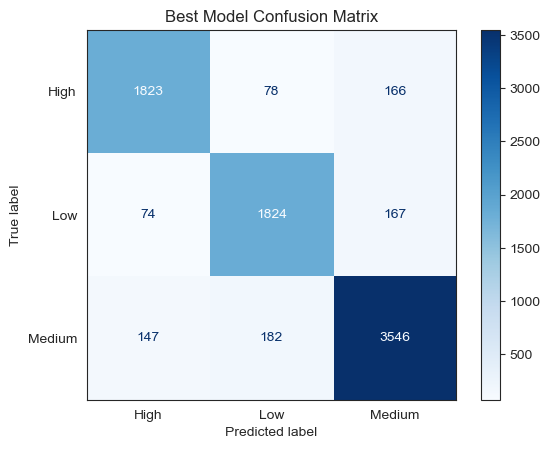

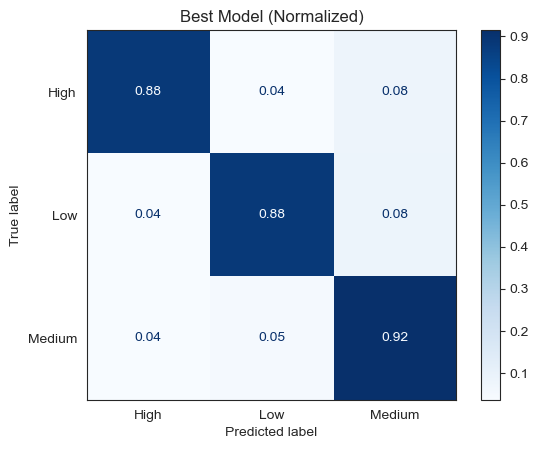

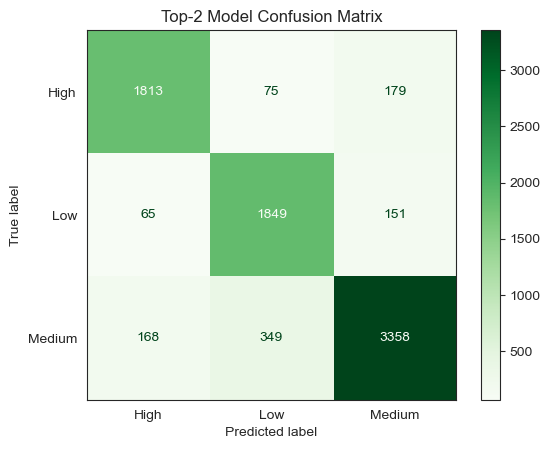

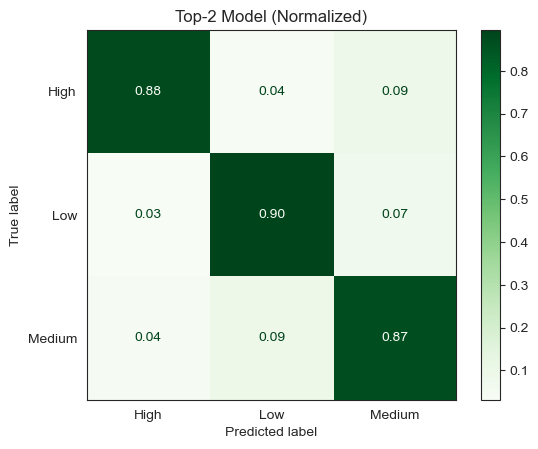

In [65]:

#==========Full features model==========
cm_best = confusion_matrix(y_test, y_pred_best)

ConfusionMatrixDisplay(
    confusion_matrix=cm_best,
    display_labels=dt_model.classes_
).plot(cmap="Blues")

plt.title("Best Model Confusion Matrix")
plt.show()

# normalized
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred_best, normalize='true'),
    display_labels=dt_model.classes_
).plot(cmap="Blues", values_format=".2f")

plt.title("Best Model (Normalized)")
plt.show()

#==========Top 2 features model==========
cm_top2 = confusion_matrix(y_test, y_pred_top2)

ConfusionMatrixDisplay(
    confusion_matrix=cm_top2,
    display_labels=top2_model.classes_
).plot(cmap="Greens")

plt.title("Top-2 Model Confusion Matrix")
plt.show()

# normalized
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred_top2, normalize='true'),
    display_labels=top2_model.classes_
).plot(cmap="Greens", values_format=".2f")

plt.title("Top-2 Model (Normalized)")
plt.show()

## Model Interpretability: Predicted Probabilities for Top-2 Feature Decision Tree (on test set)

In [91]:
import pandas as pd

# ======================================================
# 🔹 1. Predict probabilities (TOP-2 Decision Tree)
# ======================================================
y_proba = top2_model.predict_proba(X_test2)

# ======================================================
# 🔹 2. Build result dataframe
# ======================================================
result_df = pd.DataFrame({
    'Actual': y_test.values
})

prob_df = pd.DataFrame(
    y_proba,
    columns=top2_model.classes_
)

result_df = pd.concat([result_df, prob_df], axis=1)

print(result_df.head(100))

# ======================================================
# 🔹 3. Predicted class (BEST PRACTICE)
# ======================================================
result_df['Predicted'] = top2_model.predict(X_test2)

# ======================================================
# 🔹 4. Accuracy
# ======================================================
accuracy = (result_df['Predicted'] == result_df['Actual']).mean()

print("\nAccuracy:", round(accuracy, 4))

    Actual      High       Low    Medium
0     High  0.081732  0.081831  0.836436
1     High  0.055733  0.939311  0.004956
2     High  0.953977  0.029642  0.016380
3   Medium  0.049813  0.099747  0.850440
4   Medium  0.000000  0.505834  0.494166
..     ...       ...       ...       ...
95    High  0.946333  0.036989  0.016678
96  Medium  0.064448  0.041559  0.893992
97  Medium  0.000000  0.072522  0.927478
98    High  0.958100  0.024123  0.017777
99     Low  0.000000  1.000000  0.000000

[100 rows x 4 columns]

Accuracy: 0.8767


# Decision Tree Visualization (Top-2 Feature Model)

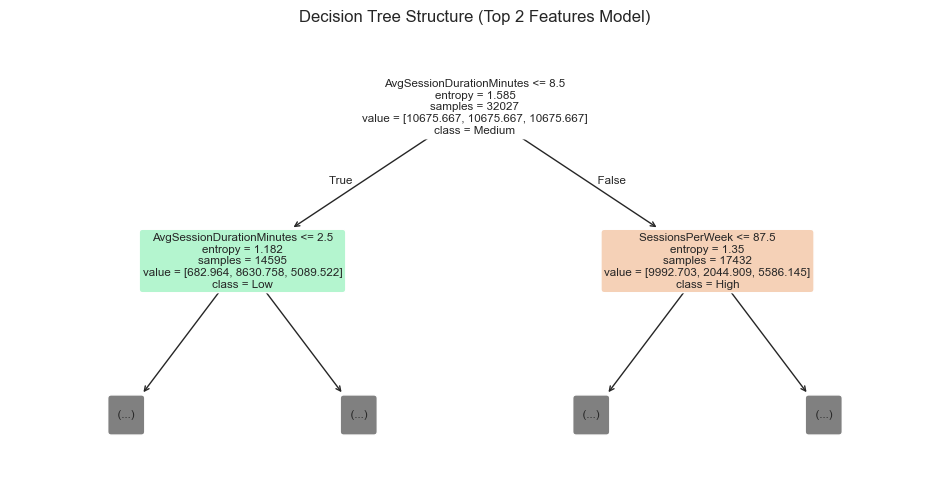

In [90]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# ======================================================
# 🔹 Decision Tree Visualization (TOP-2 MODEL)
# ======================================================
plt.figure(figsize=(12,6))

plot_tree(
    top2_model,
    feature_names=top2_features,   # use top2 features
    class_names=[str(c) for c in top2_model.classes_],
    filled=True,
    rounded=True,
    max_depth=1
)

plt.title("Decision Tree Structure (Top 2 Features Model)")
plt.show()

## Desicion Tree Model traning using GridsearchCV with full data (Gridsearch on full data, no test set)

# Analysis of the contribution of different features to model learning (full data set version)

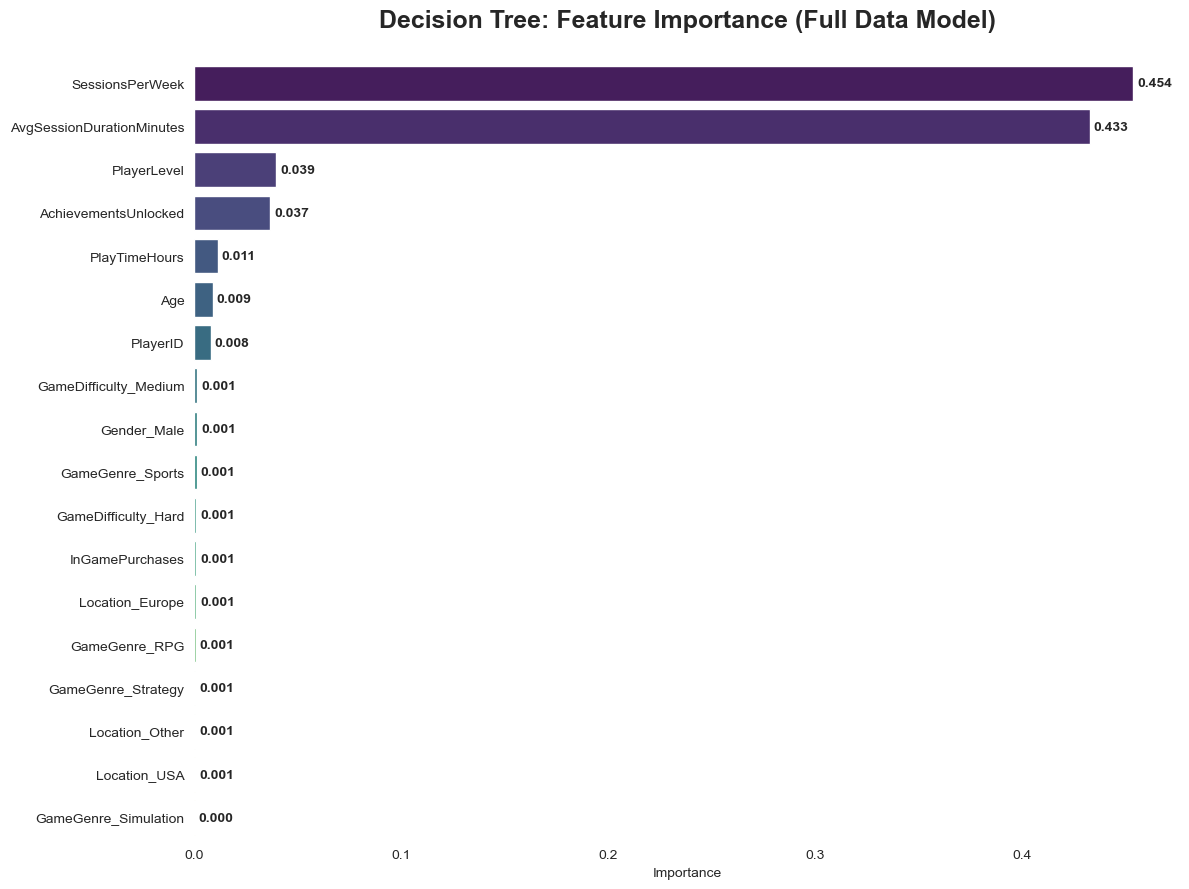

Total samples: 40034
Number of features: 18


In [83]:
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ======================================================
# 🔥 Feature Importance (FULL DATA MODEL)
# ======================================================
importances = dt_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': dt_model.feature_names_in_,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# ======================================================
# 📊 Plot
# ======================================================
plt.figure(figsize=(12, 9))
sns.set_style("white")

ax = sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df,
    palette='viridis',
    hue='Feature',
    legend=False
)

# --- Value labels ---
for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + 0.002,
        p.get_y() + p.get_height()/2,
        f'{width:.3f}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Decision Tree: Feature Importance (Full Data Model)',
          fontsize=18, fontweight='bold', pad=25)

plt.xlabel('Importance')
plt.ylabel('')
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

# ======================================================
# 📌 INFO
# ======================================================
print(f"Total samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")

## Hyperparameter Optimization of Decision Tree Using Stratified Cross-Validation on Full Dataset

In [75]:
import pandas as pd

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# =========================
# Features
# =========================
X = df.drop(columns=['EngagementLevel'])
y = df['EngagementLevel']

# =========================
# One-Hot Encoding
# =========================
X = pd.get_dummies(X, drop_first=True)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ======================================================
# GRID SEARCH (FULL DATA - NO TRAIN/TEST SPLIT)
# ======================================================
param_grid = {
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

dt_base = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)

grid_search = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search.fit(X, y)

# ======================================================
# BEST MODEL
# ======================================================
dt_model = grid_search.best_estimator_

print("\n=== BEST PARAMETERS (Decision Tree) ===")
print(grid_search.best_params_)

print("\n=== BEST CV SCORE (F1 Macro) ===")
print(grid_search.best_score_)

# ======================================================
# FINAL PREDICTION (on FULL DATA)
# ======================================================
y_pred = dt_model.predict(X)
y_proba = dt_model.predict_proba(X)

roc_auc = roc_auc_score(
    y,
    y_proba,
    multi_class='ovr',
    average='macro'
)

print("\n=== FULL DATA MODEL RESULTS ===")
print(f"ROC-AUC (on full data): {roc_auc:.4f}")
print(f"Accuracy (on full data): {accuracy_score(y, y_pred):.4f}")

print("\nClassification Report:\n")
print(classification_report(y, y_pred))


=== BEST PARAMETERS (Decision Tree) ===
{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}

=== BEST CV SCORE (F1 Macro) ===
0.8964725207762061

=== FULL DATA MODEL RESULTS ===
ROC-AUC (on full data): 0.9716
Accuracy (on full data): 0.9211

Classification Report:

              precision    recall  f1-score   support

        High       0.92      0.90      0.91     10336
         Low       0.91      0.90      0.91     10324
      Medium       0.93      0.94      0.93     19374

    accuracy                           0.92     40034
   macro avg       0.92      0.92      0.92     40034
weighted avg       0.92      0.92      0.92     40034



## Decision Tree Model Optimization Using GridSearchCV on Top-2 Selected Features

In [108]:
import pandas as pd

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# =========================
# Features
# =========================
X = df.drop(columns=['EngagementLevel'])
y = df['EngagementLevel']

# =========================
# One-Hot Encoding
# =========================
X = pd.get_dummies(X, drop_first=True)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ======================================================
# FULL DATA PRE-GRIDSEARCH
# ======================================================
param_grid = {
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

# ======================================================
# 🌿 STEP 2: GET TOP-2 FEATURES
# ======================================================
feature_importance_df = pd.DataFrame({
    'Feature': best_model_full.feature_names_in_,
    'Importance': best_model_full.feature_importances_
}).sort_values(by='Importance', ascending=False)

top2_features = feature_importance_df['Feature'].head(2).values

print("\n=== TOP 2 FEATURES ===")
print(top2_features)

# ======================================================
# 🌿 STEP 3: TOP-2 DATA (FULL DATA)
# ======================================================
X_top2 = X[top2_features]

# ======================================================
# 🌿 STEP 4: GRIDSEARCHCV (TOP-2 FEATURES ONLY)
# ======================================================
grid_search_top2 = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search_top2.fit(X_top2, y)

best_model_top2 = grid_search_top2.best_estimator_

print("\n=== TOP-2 MODEL BEST PARAMS ===")
print(grid_search_top2.best_params_)

print("\n=== TOP-2 CV BEST SCORE ===")
print(grid_search_top2.best_score_)

# ======================================================
# 🔥 STEP 5: FINAL EVALUATION (ON FULL DATA)
# ======================================================
y_pred = best_model_top2.predict(X_top2)
y_proba = best_model_top2.predict_proba(X_top2)

roc_auc = roc_auc_score(
    y,
    y_proba,
    multi_class='ovr',
    average='macro'
)
from sklearn.model_selection import cross_val_score

# ======================================================
# 📊 CV MEAN (TOP-2 MODEL)
# ======================================================
cv_scores_top2 = cross_val_score(
    best_model_top2,
    X_top2,
    y,
    cv=cv,
    scoring='f1_macro'
)

print("\n===== TOP-2 MODEL CV mean =====")
print(f"CV F1 Macro Mean: {cv_scores_top2.mean():.4f}")
print(f"CV F1 Macro Std : {cv_scores_top2.std():.4f}")

print("\n=== TOP-2 MODEL (FULL DATA) RESULTS ===")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Accuracy: {accuracy_score(y, y_pred):.4f}")

print("\nClassification Report:\n")
print(classification_report(y, y_pred))


=== TOP 2 FEATURES ===
['SessionsPerWeek' 'AvgSessionDurationMinutes']

=== TOP-2 MODEL BEST PARAMS ===
{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}

=== TOP-2 CV BEST SCORE ===
0.8756304311029031

===== TOP-2 MODEL CV mean =====
CV F1 Macro Mean: 0.8756
CV F1 Macro Std : 0.0012

=== TOP-2 MODEL (FULL DATA) RESULTS ===
ROC-AUC: 0.9554
Accuracy: 0.8838

Classification Report:

              precision    recall  f1-score   support

        High       0.90      0.89      0.89     10336
         Low       0.82      0.90      0.86     10324
      Medium       0.92      0.87      0.89     19374

    accuracy                           0.88     40034
   macro avg       0.88      0.89      0.88     40034
weighted avg       0.89      0.88      0.88     40034



## Decision Tree Feature Selection and Performance Comparison: Full Model vs Top-2 Features

In [78]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# ======================================================
# 🔥 FULL MODEL PREDICTION
# ======================================================
y_pred_full = best_model_full.predict(X)
y_proba_full = best_model_full.predict_proba(X)

roc_full = roc_auc_score(
    y,
    y_proba_full,
    multi_class='ovr',
    average='macro'
)

acc_full = accuracy_score(y, y_pred_full)
f1_full = f1_score(y, y_pred_full, average='macro')

# ======================================================
# 🌿 TOP-2 MODEL PREDICTION
# ======================================================
y_pred_top2 = best_model_top2.predict(X_top2)
y_proba_top2 = best_model_top2.predict_proba(X_top2)

roc_top2 = roc_auc_score(
    y,
    y_proba_top2,
    multi_class='ovr',
    average='macro'
)

acc_top2 = accuracy_score(y, y_pred_top2)
f1_top2 = f1_score(y, y_pred_top2, average='macro')

# ======================================================
# 📊 GAP ANALYSIS
# ======================================================
print("\n================ FINAL GAP COMPARISON ================\n")

print("🔹 FULL MODEL")
print(f"Accuracy : {acc_full:.4f}")
print(f"F1 Macro : {f1_full:.4f}")
print(f"ROC-AUC  : {roc_full:.4f}")

print("\n🔹 TOP-2 MODEL")
print(f"Accuracy : {acc_top2:.4f}")
print(f"F1 Macro : {f1_top2:.4f}")
print(f"ROC-AUC  : {roc_top2:.4f}")

print("\n================ GAP (FULL - TOP2) ================\n")

print(f"Accuracy gap : {acc_full - acc_top2:.4f}")
print(f"F1 gap       : {f1_full - f1_top2:.4f}")
print(f"ROC-AUC gap  : {roc_full - roc_top2:.4f}")


================ FINAL GAP COMPARISON ================

🔹 FULL MODEL
Accuracy : 0.9211
F1 Macro : 0.9171
ROC-AUC  : 0.9716

🔹 TOP-2 MODEL
Accuracy : 0.8838
F1 Macro : 0.8812
ROC-AUC  : 0.9554

================ GAP (FULL - TOP2) ================

Accuracy gap : 0.0373
F1 gap       : 0.0359
ROC-AUC gap  : 0.0162


 ## Confusion Matrix Comparison: Full Model vs Top-2 Feature Model on full dataset

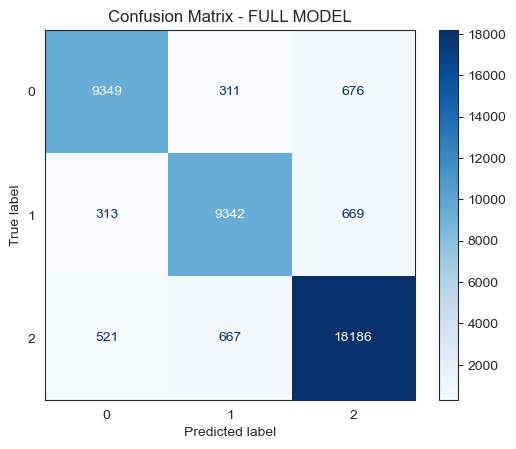

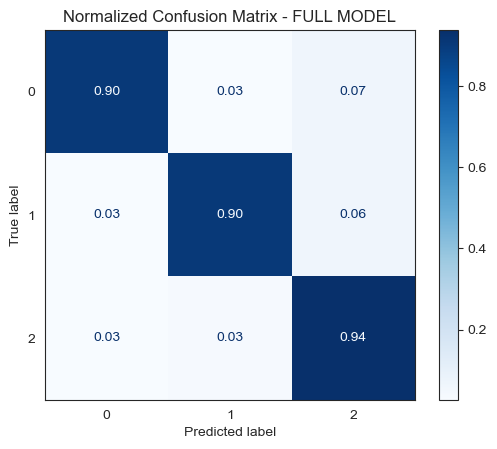

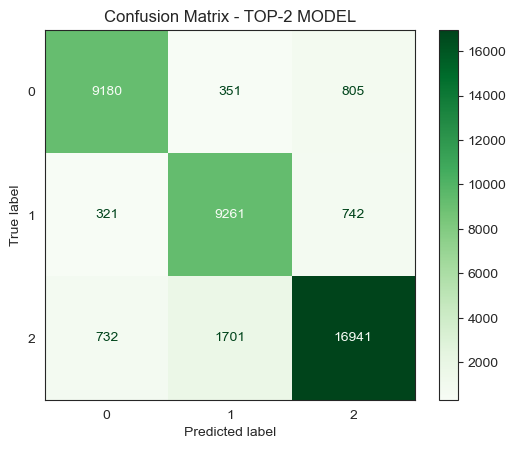

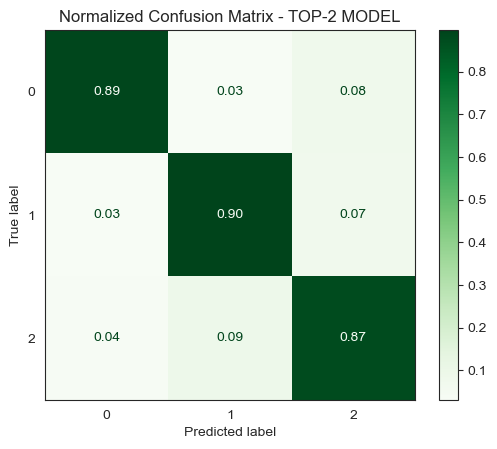

In [80]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ======================================================
# 🌳 FULL MODEL CONFUSION MATRIX
# ======================================================
cm_full = confusion_matrix(y, y_pred_full)

disp_full = ConfusionMatrixDisplay(confusion_matrix=cm_full)
disp_full.plot(cmap="Blues")
plt.title("Confusion Matrix - FULL MODEL")
plt.show()

# ======================================================
# 🌿 FULL MODEL NORMALIZED
# ======================================================
cm_full_norm = cm_full.astype("float") / cm_full.sum(axis=1)[:, None]

disp_full_norm = ConfusionMatrixDisplay(confusion_matrix=cm_full_norm)
disp_full_norm.plot(cmap="Blues", values_format=".2f")
plt.title("Normalized Confusion Matrix - FULL MODEL")
plt.show()

# ======================================================
# 🌿 TOP-2 MODEL CONFUSION MATRIX
# ======================================================
cm_top2 = confusion_matrix(y, y_pred_top2)

disp_top2 = ConfusionMatrixDisplay(confusion_matrix=cm_top2)
disp_top2.plot(cmap="Greens")
plt.title("Confusion Matrix - TOP-2 MODEL")
plt.show()

# ======================================================
# 🌿 TOP-2 MODEL NORMALIZED
# ======================================================
cm_top2_norm = cm_top2.astype("float") / cm_top2.sum(axis=1)[:, None]

disp_top2_norm = ConfusionMatrixDisplay(confusion_matrix=cm_top2_norm)
disp_top2_norm.plot(cmap="Greens", values_format=".2f")
plt.title("Normalized Confusion Matrix - TOP-2 MODEL")
plt.show()

# Decision Tree Visualization (Top-2 Feature Model, Full dataset version)

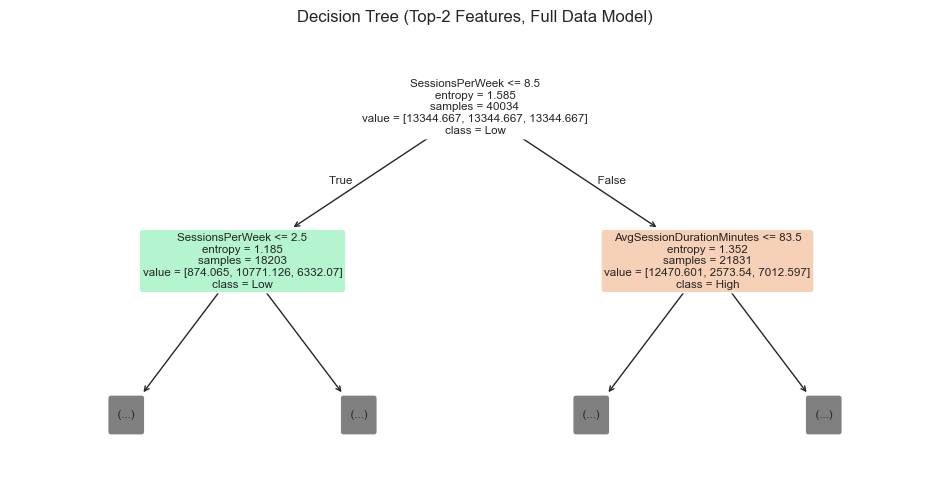

In [82]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# ======================================================
# 🌿 TOP-2 DECISION TREE VISUALIZATION (FULL DATA MODEL)
# ======================================================
plt.figure(figsize=(12,6))

plot_tree(
    best_model_top2,
    feature_names=top2_features,   # only top2 features
    class_names=[str(c) for c in best_model_top2.classes_],
    filled=True,
    rounded=True,
    max_depth=1
)

plt.title("Decision Tree (Top-2 Features, Full Data Model)")
plt.show()